## Module 5 Class activities
This notebook is a starting point for the exercises and activities that we'll do in class. We'll do an extension of the random forests classifier, looking at a continuous variable.

Before you attempt any of these activities, make sure to watch the video lectures for this module.

### Classification: NYC evictions
We'll look at the factors that are associated with evictions in New York City. Perhaps a machine learning model can identify the types of places that are vulnerable to eviction, and target renter assistance programs more effectively?

#### Loading in the data

Let's start by loading in the [eviction dataset](https://data.cityofnewyork.us/City-Government/Evictions/6z8x-wfk4) via Socrata.

<div class="alert alert-block alert-info">

<strong>Exercise:</strong> Import the data from Socrata via the API into a pandas DataFrame.
</div>

*Hints*:
- Look back at Week 1 if you need a refresher on using Socrata
- There are about 70,000 rows in the dataset. So remember to add `?$limit=100000` to the end of the URL that you pass to `requests.get()`. Otherwise, you'll just get the first 1,000 rows. (The limit can be anything comfortably above 70000.)

In [1]:
import requests
import json
import pandas as pd
import geopandas as gpd

# your code here

url = 'https://data.cityofnewyork.us/resource/6z8x-wfk4.json?$limit=100000'
r = requests.get(url)
df = pd.DataFrame(json.loads(r.content))
len(df)

100000

<div class="alert alert-block alert-info">

<strong>Exercise:</strong> Convert your dataframe to a GeoDataFrame, using the latitude and longitude columns.

<Axes: >

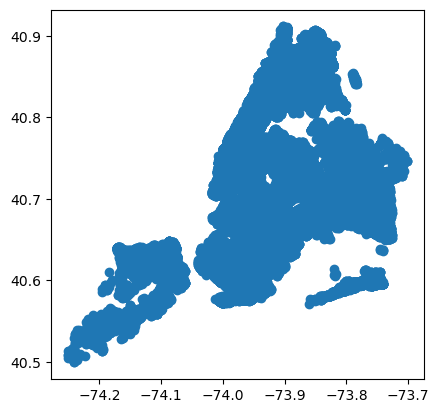

In [2]:
# your code here 
gdf = gpd.GeoDataFrame(df, 
            geometry = gpd.points_from_xy(
                df.longitude, df.latitude, crs='EPSG:4326'))
gdf.plot() # make sure it looks ok

Now let's import some census data. We could use `cenpy` or the Census Bureau API. But to keep things simple so that we can focus on the spatial joins and the machine learning, I downloaded the block group-level 2019 ACS data for New York from the [Census Bureau](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-data.html). To save space, I clipped it to the 5 NYC counties.

It's in your repository, and we can load it in as follows. If you aren't familiar with a GeoPackage (GPKG) format, think of it as a "new and improved shapefile." [Here's a good overview.](https://towardsdatascience.com/why-you-need-to-use-geopackage-files-instead-of-shapefile-or-geojson-7cb24fe56416)

In [3]:
bgs = gpd.read_file('../classes/data/nyc_bgs.gpkg')
bgs.head()

,GEOID,B01001e1,B01001e10,B01001e11,B01001e12,B01001e13,B01001e14,B01001e15,B01001e16,B01001e17,...,B19001e8,B19001e9,B22010e1,B22010e2,B22010e3,B22010e4,B22010e5,B22010e6,B22010e7,geometry
0,15000US360050175002,656,39,0,0,0,18,14,0,22,...,11,0,358,214,139,75,144,107,37,"POLYGON ((-73.9157 40.83054, -73.91485 40.8302..."
1,15000US360050141001,1228,0,35,96,26,45,28,0,54,...,34,0,503,291,226,65,212,70,142,"POLYGON ((-73.91661 40.82499, -73.91592 40.825..."
2,15000US360050145001,2716,44,192,33,38,76,30,64,93,...,137,83,972,534,316,218,438,7,431,"POLYGON ((-73.90584 40.83106, -73.90505 40.832..."
3,15000US360050075002,3488,43,109,122,169,19,51,139,22,...,63,37,1188,470,300,170,718,147,571,"POLYGON ((-73.91035 40.81995, -73.91022 40.820..."
4,15000US360050418001,657,0,38,5,11,21,14,43,25,...,0,0,217,87,18,69,130,41,89,"POLYGON ((-73.86288 40.89515, -73.86146 40.897..."


Note that the variables aren't particularly carefully selected - I just threw in many of the demographic and housing variables. 

Nor are the variable names particularly informative, but the full names are in a file in the repository.

In [4]:
# note it is tab-sepated, not comma separated
# so we use the sep='\t' argument

col_names = pd.read_csv('../classes/data/BG_METADATA_2019.txt', sep='\t', index_col='Short_Name')
col_names.head()

,Full_Name
Short_Name,
B01001e1,SEX BY AGE: Total: Total population -- (Estimate)
B01001m1,SEX BY AGE: Total: Total population -- (Margin...
B01001e2,SEX BY AGE: Male: Total population -- (Estimate)
B01001m2,SEX BY AGE: Male: Total population -- (Margin ...
B01001e3,SEX BY AGE: Male: Under 5 years: Total populat...


So you can see the definition of the column like this. (I don't recommend renaming the `bg` column names, because the full names are so long.)

In [5]:
col_names.loc['B01001e1']

Full_Name    SEX BY AGE: Total: Total population -- (Estimate)
Name: B01001e1, dtype: object

#### Spatial join
Now let's do the spatial join. Again, let's follow our three step process.

1. Use a spatial join to add the `GEOID` column to the evictions dataframe. *Hint:* Check your projections.
2. Group by `GEOID` to get a count of evictions per block group. If you have a `Series`, give it a name - maybe `n_evictions`
3. Join those counts back - a tabular join based on the index

<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> Add a count of evictions per census block group to your <strong>bgs</strong> GeoDataFrame, using the 3-step process above.
</div>

In [6]:
# your code here

# spatial join
# match the CRS
bgs.to_crs('EPSG:4326', inplace=True)

gdf2 = gpd.sjoin(gdf, bgs, predicate='intersects')

# count 
n_evictions = gdf2.groupby('GEOID').size()
n_evictions.name = 'n_evictions'

# join back
bgs = bgs.set_index('GEOID').join(n_evictions)
bgs.fillna({'n_evictions':0}, inplace=True)
bgs.head()

,B01001e1,B01001e10,B01001e11,B01001e12,B01001e13,B01001e14,B01001e15,B01001e16,B01001e17,B01001e18,...,B19001e9,B22010e1,B22010e2,B22010e3,B22010e4,B22010e5,B22010e6,B22010e7,geometry,n_evictions
GEOID,,,,,,,,,,,,,,,,,,,,,
15000US360050175002,656,39,0,0,0,18,14,0,22,0,...,0,358,214,139,75,144,107,37,"POLYGON ((-73.9157 40.83054, -73.91485 40.8302...",35.0
15000US360050141001,1228,0,35,96,26,45,28,0,54,0,...,0,503,291,226,65,212,70,142,"POLYGON ((-73.91661 40.82499, -73.91592 40.825...",60.0
15000US360050145001,2716,44,192,33,38,76,30,64,93,71,...,83,972,534,316,218,438,7,431,"POLYGON ((-73.90584 40.83106, -73.90505 40.832...",55.0
15000US360050075002,3488,43,109,122,169,19,51,139,22,31,...,37,1188,470,300,170,718,147,571,"POLYGON ((-73.91035 40.81995, -73.91022 40.820...",107.0
15000US360050418001,657,0,38,5,11,21,14,43,25,2,...,0,217,87,18,69,130,41,89,"POLYGON ((-73.86287 40.89515, -73.86146 40.897...",26.0


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Do a quick-and-dirty map of the number of evictions. This will help identify any data holes.
</div>

<Axes: >

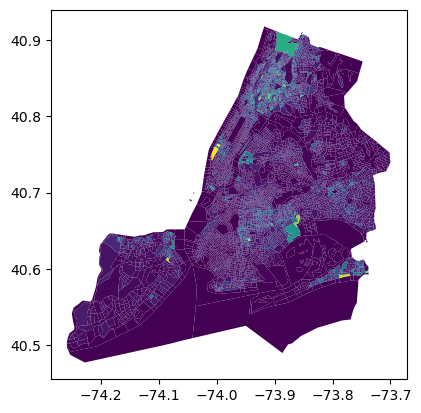

In [7]:
bgs.plot('n_evictions')

#### Random forests regressor
Now we have our data set. Let's estimate a random forests model.

In contrast to the examples in the lecture, we are trying to predict a continuous variable - the number of evictions. So our classifier isn't appropriate. 

However, there is a similar model: the [random forest regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor). It works almost identically to the classifier. The main difference from a user perspective is assessing model performance - a confusion matrix doesn't work here.

You'll need to follow the following steps:
- choose your x variables. (Your y variable will be `n_evictions`)
- Drop Null values if needed
- split your dataset into training and testing portions
- estimate (fit) the model

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Estimate a random forest regressor model to predict the number of evictions per census tract.</div>

In [8]:
bgs.columns.tolist()

['B01001e1',
 'B01001e10',
 'B01001e11',
 'B01001e12',
 'B01001e13',
 'B01001e14',
 'B01001e15',
 'B01001e16',
 'B01001e17',
 'B01001e18',
 'B01001e19',
 'B02001e1',
 'B02001e10',
 'B02001e2',
 'B02001e3',
 'B02001e4',
 'B02001e5',
 'B02001e6',
 'B02001e7',
 'B02001e8',
 'B02001e9',
 'B03002e12',
 'B03002e3',
 'B09002e1',
 'B09002e10',
 'B09002e11',
 'B09002e12',
 'B09002e13',
 'B09002e14',
 'B09002e15',
 'B09002e16',
 'B09002e17',
 'B09002e18',
 'B09002e19',
 'B09002e2',
 'B09002e20',
 'B09002e3',
 'B09002e4',
 'B09002e5',
 'B09002e6',
 'B09002e7',
 'B09002e8',
 'B09002e9',
 'B09019e1',
 'B09019e10',
 'B09019e11',
 'B09019e12',
 'B09019e13',
 'B09019e14',
 'B09019e15',
 'B09019e16',
 'B09019e17',
 'B09019e18',
 'B09019e19',
 'B09019e2',
 'B09019e20',
 'B09019e21',
 'B09019e22',
 'B09019e23',
 'B09019e24',
 'B09019e25',
 'B09019e26',
 'B09019e3',
 'B09019e4',
 'B09019e5',
 'B09019e6',
 'B09019e7',
 'B09019e8',
 'B09019e9',
 'B09021e1',
 'B09021e10',
 'B09021e11',
 'B09021e12',
 'B09021

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# your code here
xvars = ['B01001e1',
 'B01001e10',
 'B01001e11',
 'B01001e12',
 'B01001e13',
 'B01001e14',
 'B01001e15',
 'B01001e16',
 'B01001e17',
 'B01001e18',
 'B01001e19',
 'B02001e1',
 'B02001e10',
 'B02001e2',
 'B02001e3',
 'B02001e4',
 'B02001e5',
 'B02001e6',
 'B02001e7',
 'B02001e8',
 'B02001e9',
 'B03002e12',
 'B03002e3',
 'B09002e1',
 'B09002e10',
 'B09002e11',
 'B09002e12',
 'B09002e13',
 'B09002e14',
 'B09002e15',
 'B09002e16',
 'B09002e17',
 'B09002e18',
 'B09002e19',
 'B09002e2',
 'B09002e20',
 'B09002e3',
 'B09002e4',
 'B09002e5',
 'B09002e6',
 'B09002e7',
 'B09002e8',
 'B09002e9',
 'B09019e1',
 'B09019e10',
 'B09019e11',
 'B09019e12',
 'B09019e13',
 'B09019e14',
 'B09019e15',
 'B09019e16',
 'B09019e17',
 'B09019e18',
 'B09019e19',
 'B09019e2',
 'B09019e20',
 'B09019e21',
 'B09019e22',
 'B09019e23',
 'B09019e24',
 'B09019e25',
 'B09019e26',
 'B09019e3',
 'B09019e4',
 'B09019e5',
 'B09019e6',
 'B09019e7',
 'B09019e8',
 'B09019e9',
 'B09021e1',
 'B09021e10',
 'B09021e11',
 'B09021e12',
 'B09021e13',
 'B09021e14',
 'B09021e15',
 'B09021e16',
 'B09021e17',
 'B09021e18',
 'B09021e19',
 'B09021e2',
 'B09021e20',
 'B09021e21',
 'B09021e22',
 'B09021e23',
 'B09021e24',
 'B09021e25',
 'B09021e26',
 'B09021e27',
 'B09021e28',
 'B09021e3',
 'B09021e4',
 'B09021e5',
 'B09021e6',
 'B09021e7',
 'B09021e8',
 'B09021e9',
 'B11001e1',
 'B11001e2',
 'B11001e3',
 'B11001e4',
 'B11001e5',
 'B11001e6',
 'B11001e7',
 'B11001e8',
 'B11001e9',
 'B11005e1',
 'B11005e10',
 'B11005e11',
 'B11005e12',
 'B11005e13',
 'B11005e14',
 'B11005e15',
 'B11005e16',
 'B11005e17',
 'B11005e18',
 'B11005e19',
 'B11005e2',
 'B11005e3',
 'B11005e4',
 'B11005e5',
 'B11005e6',
 'B11005e7',
 'B11005e8',
 'B11005e9',
 'B11012e1',
 'B11012e10',
 'B11012e11',
 'B11012e12',
 'B11012e13',
 'B11012e14',
 'B11012e15',
 'B11012e16',
 'B11012e17',
 'B11012e2',
 'B11012e3',
 'B11012e4',
 'B11012e5',
 'B11012e6',
 'B11012e7',
 'B11012e8',
 'B11012e9',
 'B11016e1',
 'B11016e10',
 'B11016e11',
 'B11016e12',
 'B11016e13',
 'B11016e14',
 'B11016e15',
 'B11016e16',
 'B11016e2',
 'B11016e3',
 'B11016e4',
 'B11016e5',
 'B11016e6',
 'B11016e7',
 'B11016e8',
 'B11016e9',
 'B17010e1',
 'B17010e10',
 'B17010e11',
 'B17010e12',
 'B17010e13',
 'B17010e14',
 'B17010e15',
 'B17010e16',
 'B17010e17',
 'B17010e18',
 'B17010e19',
 'B17010e2',
 'B17010e20',
 'B17010e21',
 'B17010e22',
 'B17010e23',
 'B17010e24',
 'B17010e25',
 'B17010e26',
 'B17010e27',
 'B17010e28',
 'B17010e29',
 'B17010e3',
 'B17010e30',
 'B17010e31',
 'B17010e32',
 'B17010e33',
 'B17010e34',
 'B17010e35',
 'B17010e36',
 'B17010e37',
 'B17010e38',
 'B17010e39',
 'B17010e4',
 'B17010e40',
 'B17010e41',
 'B17010e5',
 'B17010e6',
 'B17010e7',
 'B17010e8',
 'B17010e9',
 'B17017e1',
 'B17017e10',
 'B17017e11',
 'B17017e12',
 'B17017e13',
 'B17017e14',
 'B17017e15',
 'B17017e16',
 'B17017e17',
 'B17017e18',
 'B17017e19',
 'B17017e2',
 'B17017e20',
 'B17017e21',
 'B17017e22',
 'B17017e23',
 'B17017e24',
 'B17017e25',
 'B17017e26',
 'B17017e27',
 'B17017e28',
 'B17017e29',
 'B17017e3',
 'B17017e30',
 'B17017e31',
 'B17017e32',
 'B17017e33',
 'B17017e34',
 'B17017e35',
 'B17017e36',
 'B17017e37',
 'B17017e38',
 'B17017e39',
 'B17017e4',
 'B17017e40',
 'B17017e41',
 'B17017e42',
 'B17017e43',
 'B17017e44',
 'B17017e45',
 'B17017e46',
 'B17017e47',
 'B17017e48',
 'B17017e49',
 'B17017e5',
 'B17017e50',
 'B17017e51',
 'B17017e52',
 'B17017e53',
 'B17017e54',
 'B17017e55',
 'B17017e56',
 'B17017e57',
 'B17017e58',
 'B17017e59',
 'B17017e6',
 'B17017e7',
 'B17017e8',
 'B17017e9',
 'B19001e1',
 'B19001e10',
 'B19001e11',
 'B19001e12',
 'B19001e13',
 'B19001e14',
 'B19001e15',
 'B19001e16',
 'B19001e17',
 'B19001e2',
 'B19001e3',
 'B19001e4',
 'B19001e5',
 'B19001e6',
 'B19001e7',
 'B19001e8',
 'B19001e9',
 'B22010e1',
 'B22010e2',
 'B22010e3',
 'B22010e4',
 'B22010e5',
 'B22010e6',
 'B22010e7']
yvar = 'n_evictions'

In [10]:
df_to_fit = bgs[xvars+[yvar]].dropna()
X_train, X_test, y_train, y_test = train_test_split(
    df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)
print(len(X_train), len(y_train) )
print(len(X_test), len(y_test) )

4869 4869
1624 1624


In [11]:
#機械学習ライブラリ scikit-learn の中からRandomForestRegressorをインポート
#今回は分類ではなく数値予測（回帰）をしたいので RandomForestRegressorを使う
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 50, random_state = 1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=1)

In [12]:
y_pred = rf.predict(X_test)
y_pred

array([12.32,  3.66,  4.16, ..., 31.26, 13.5 , 18.94])

In [13]:
print(len(X_test), len(y_pred))

1624 1624


In [14]:
print('Predicted fraction True: {:.4f}. Actual fraction True: {:.4f}'.format(
    y_pred.mean(), y_test.mean()))

Predicted fraction True: 14.2932. Actual fraction True: 14.0720


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Examine some of your trees in the random forest. What do they tell you?</div>

In [ ]:
# your code here



<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Experiment with different model hyperparameters and variables. Discuss your rationale and the results with a neighbor.</div>

In [15]:
#パラメータの種類
#n_estimators：決定木の本数（例：50→100や200）
#max_depth：各決定木の深さ（例：10や20で制限してみる）
#min_samples_split：ノードを分割するために必要な最小サンプル数
#min_samples_leaf：葉ノードに必要な最小サンプル数
#max_features：分割に使う特徴量の割合（例: "sqrt", "log2", 0.5）

In [16]:
# your code here
#MLで必要なのは結局この4つだけ（変数の投入→random forestの数の設定→trainを入れる→testを入れる）
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)

rf2 = RandomForestRegressor(n_estimators = 50, random_state = 1)

rf2.fit(X_train2, y_train2)

y_pred2 = rf2.predict(X_test)

In [17]:
print('Predicted fraction True: {:.4f}. Actual fraction True: {:.4f}'.format(
    y_pred2.mean(), y_test2.mean()))

Predicted fraction True: 14.3540. Actual fraction True: 14.0720


In [18]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)

rf3 = RandomForestRegressor(n_estimators = 50, bootstrap=False, random_state = 1)
rf3.fit(X_train3, y_train3)

y_pred3 = rf3.predict(X_test)

In [19]:
print('Predicted fraction True: {:.4f}. Actual fraction True: {:.4f}'.format(
    y_pred3.mean(), y_test3.mean()))

Predicted fraction True: 14.4574. Actual fraction True: 14.0720


The following questions relate to some of the material in Module 6. You might want to wait until watching those lectures. Then come back and complete these tasks.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Assess the fit of your model.</div>

Remember, the confusion matrix and accuracy scores don't apply here. Some ideas for continuous variables are [here](https://stackoverflow.com/questions/50789508/random-forest-regression-how-do-i-analyse-its-performance-python-sklearn). You could also plot actual vs predicted values.

In [24]:
import numpy as np
from sklearn import metrics

print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error (MAE): 7.326298804871837
Mean Squared Error (MSE): 147.08293869571594
Root Mean Squared Error (RMSE): 12.127775504836654


In [ ]:
#連続変数なので、y_predをy軸に、y_testをx軸にした図を書いてみればいい

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Which variables are most important in your predictions? Plot the forest importances.</div>

RACE: Total: Black or African American alone: Total population -- (Estimate)
RECEIPT OF FOOD STAMPS/SNAP IN THE PAST 12 MONTHS BY DISABILITY STATUS FOR HOUSEHOLDS: Household received Food Stamps/SNAP in the past 12 months: Households -- (Estimate)
HOUSEHOLDS BY PRESENCE OF PEOPLE UNDER 18 YEARS BY HOUSEHOLD TYPE: Other family: Households -- (Estimate)
HISPANIC OR LATINO ORIGIN BY RACE: Hispanic or Latino: Total population -- (Estimate)
POVERTY STATUS IN THE PAST 12 MONTHS BY HOUSEHOLD TYPE BY AGE OF HOUSEHOLDER: Income in the past 12 months below poverty level: Households -- (Estimate)
RACE: Total: Some other race alone: Total population -- (Estimate)
HOUSEHOLDS BY TYPE: Male householder, no spouse or partner present: Households -- (Estimate)
HOUSEHOLD TYPE (INCLUDING LIVING ALONE): Other family: Households -- (Estimate)
HOUSEHOLD INCOME IN THE PAST 12 MONTHS (IN 2019 INFLATION-ADJUSTED DOLLARS): Total: $50,000 to $59,999: Households -- (Estimate)
LIVING ARRANGEMENTS OF ADULTS 18 YEARS

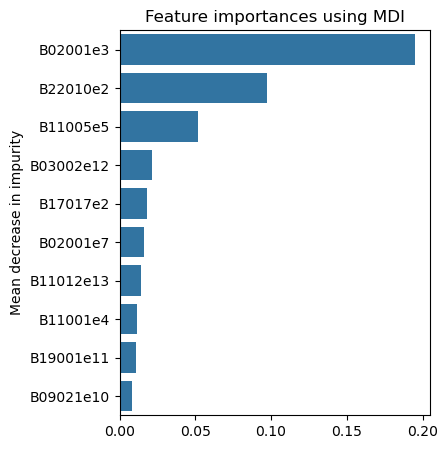

In [32]:
# your code here
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns)
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

forest_importances.sort_values(inplace=True, ascending=False)

fig, ax = plt.subplots(figsize=(4,5))
#x軸とy軸を入れ替える
sns.barplot(x=forest_importances.values[:10], y=forest_importances[:10].index, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")

for col_name in forest_importances.index.values[:10]:
    print(col_names.loc[col_name].values[0])

In [21]:
# your code here

<div class="alert alert-block alert-info">
<h3>What you should have learned</h3>
<ul>
  <li>Get more practice with spatial joins and Socrata.</li>
  <li>Learn how to estimate a random forests model for continuous data.</li>
</ul>
</div>